# Customer Churn Prediction

### Objective
The objective of this project is to predict whether a customer is likely to **churn (leave the service)** or **stay** using machine learning.

### Tools & Technologies
- Python
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn

### Dataset Information
The dataset contains customer information related to their services, account details, and churn status.

### Dataset Columns

The dataset contains the following 21 columns:

1. `customerID` – Unique ID of each customer
2. `gender` – Customer's gender
3. `SeniorCitizen` – Whether the customer is a senior citizen
4. `Partner` – Whether the customer has a partner
5. `Dependents` – Whether the customer has dependents
6. `tenure` – Number of months the customer has stayed with the company
7. `PhoneService` – Whether the customer has phone service
8. `MultipleLines` – Whether the customer has multiple phone lines
9. `InternetService` – Type of internet service
10. `OnlineSecurity` – Whether online security service is used
11. `OnlineBackup` – Whether online backup service is used
12. `DeviceProtection` – Whether device protection service is used
13. `TechSupport` – Whether technical support service is used
14. `StreamingTV` – Whether the customer uses streaming TV
15. `StreamingMovies` – Whether the customer uses streaming movies
16. `Contract` – Type of customer contract
17. `PaperlessBilling` – Whether the customer uses paperless billing
18. `PaymentMethod` – Customer's payment method
19. `MonthlyCharges` – Monthly amount charged to the customer
20. `TotalCharges` – Total amount charged to the customer
21. `Churn` – Target variable indicating whether the customer left the service

## Importing Required Libraries

In [267]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading

In [179]:
path='/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df=pd.read_csv(path)

## Understanding Dataset

In [180]:
df.shape

(7043, 21)

In [181]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [182]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [183]:
df.duplicated().sum()

np.int64(0)

In [184]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [185]:
df=df.drop(columns=['customerID'],axis=1)


The `customerID` column does not provide useful information for predicting whether a customer will churn, so I will remove it before building the model.

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [268]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [187]:
df['TotalCharges'].nunique()

6531

In [188]:
df['TotalCharges']=df['TotalCharges'].replace(' ','0.0')

In [189]:
df['TotalCharges']=df['TotalCharges'].astype('float')

## Identifying Categorical and Numerical Features

In [190]:
cat_cols=df.select_dtypes(include=('object')).columns.tolist()

In [191]:
num_cols=df.select_dtypes(exclude=('object')).columns.tolist()

In [192]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [193]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

## Exploratory Data Analysis

## Distribution of Categorical Features

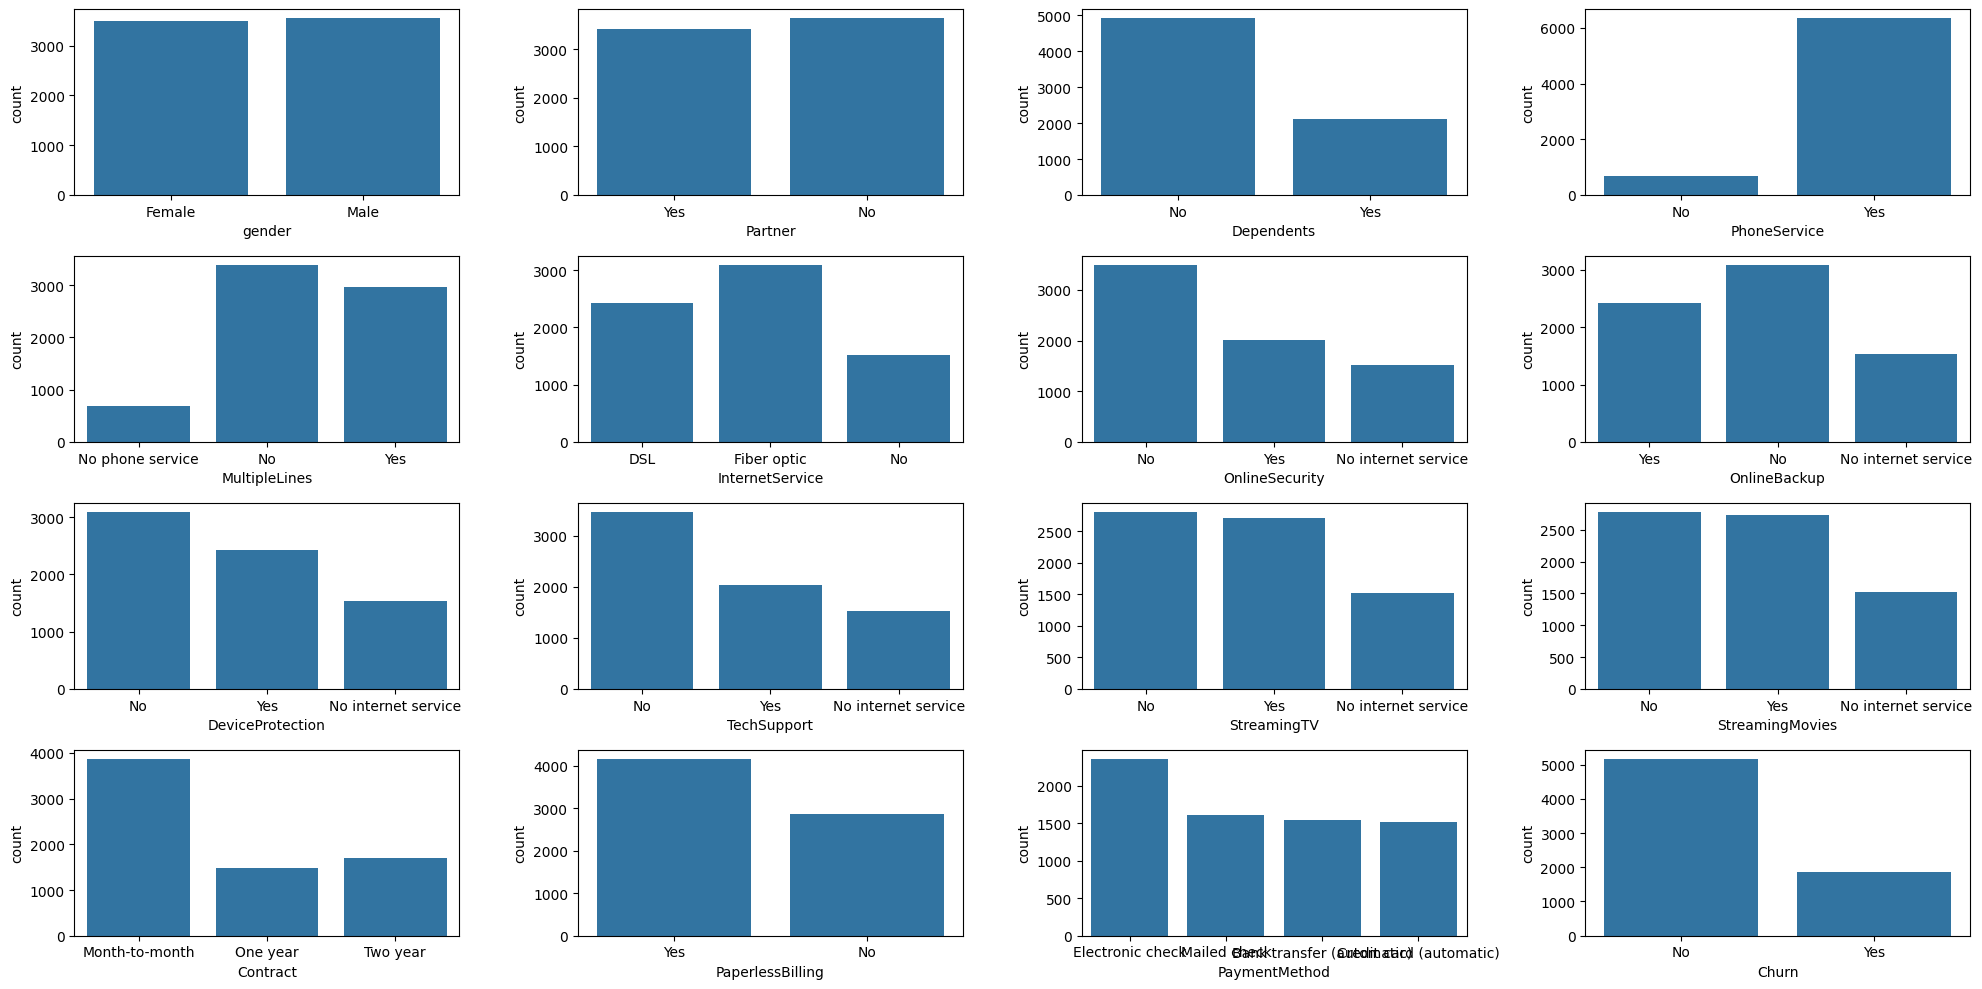

In [194]:
fig,ax=plt.subplots(4,4,figsize=(20,10))
ax=ax.flatten()
for i,column in enumerate(cat_cols):
    sns.countplot(x=df[column],ax=ax[i])
plt.tight_layout()
plt.show()

<Axes: xlabel='SeniorCitizen'>

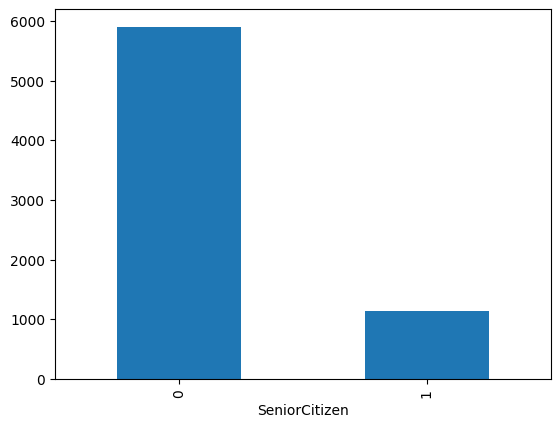

In [195]:
df['SeniorCitizen'].value_counts().plot(kind='bar')

In [196]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

## Distribution of Numerical Features

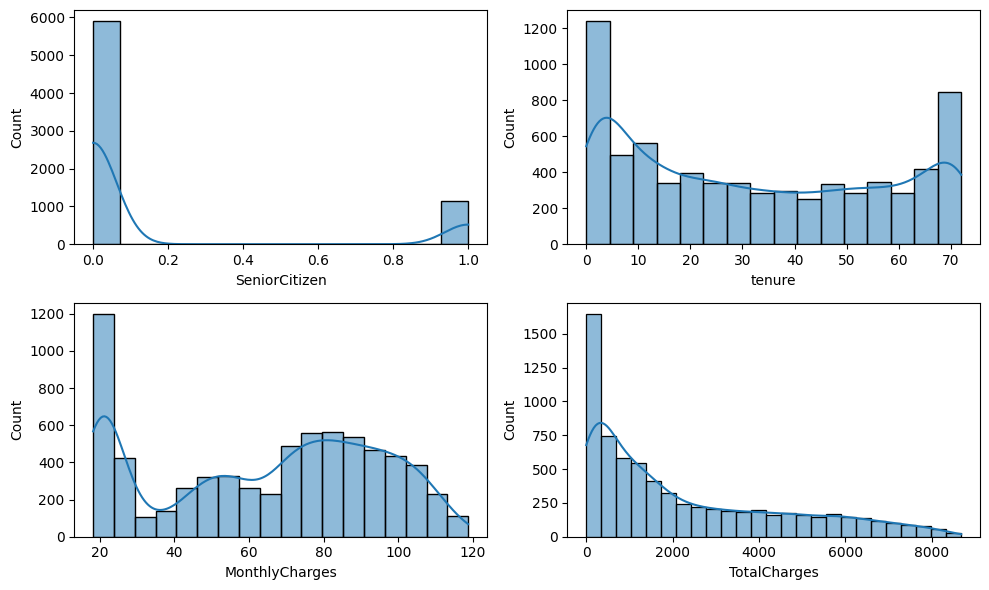

In [197]:
fig,ax=plt.subplots(2,2,figsize=(10,6))
ax=ax.flatten()
for i,column in enumerate(num_cols):
    sns.histplot(x=df[column],ax=ax[i],kde=True)
plt.tight_layout()
plt.show()

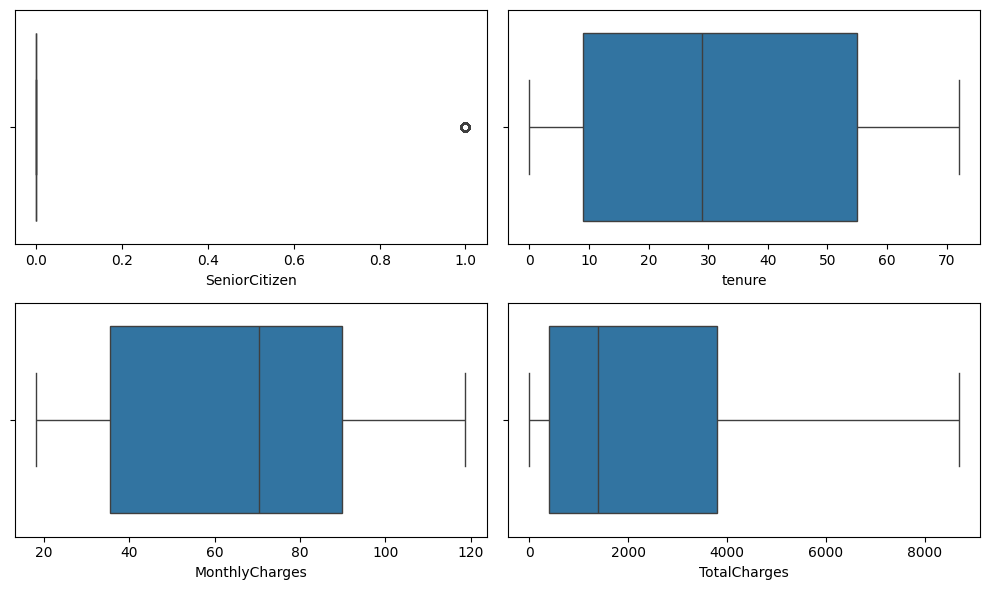

In [198]:
fig,ax=plt.subplots(2,2,figsize=(10,6))
ax=ax.flatten()
for i,column in enumerate(num_cols):
    sns.boxplot(x=df[column],ax=ax[i],vert=False)
plt.tight_layout()
plt.show()

In [200]:
df['Churn'].head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [201]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [202]:
df['Churn']=df['Churn'].astype('int')

In [203]:
df['Churn'].dtypes

dtype('int64')

## Correlation Analysis

<Axes: >

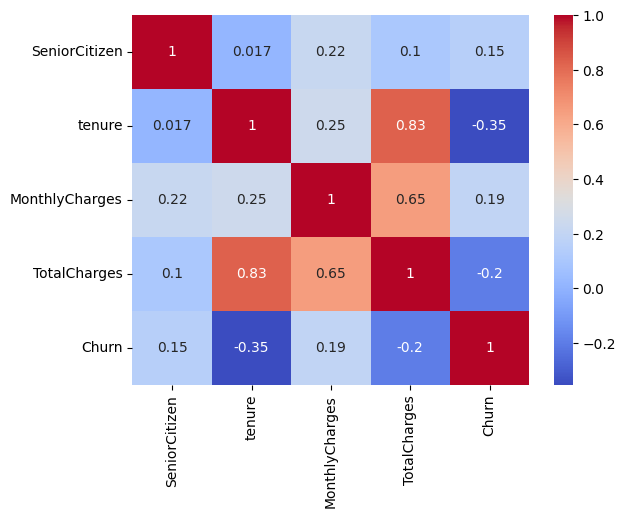

In [204]:
corr_matrix=df.select_dtypes('number').corr()
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

## Data Preprocessing

In [269]:
from sklearn.model_selection import train_test_split,KFold,StratifiedKFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Train-Test Split

In [242]:
X=df.drop(columns=['Churn'],axis=1)
y=df['Churn']

In [243]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [244]:
print("shape of traning data",X_train.shape)
print("shape of testing data",X_test.shape)

shape of traning data (5634, 19)
shape of testing data (1409, 19)


In [245]:
categorical_features=['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [246]:
numerical_features=['tenure', 'MonthlyCharges', 'TotalCharges','SeniorCitizen']

In [247]:
columns_cat=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)
columns_num=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

In [248]:
preprocess=ColumnTransformer(
    transformers=[
        ('cat',columns_cat,categorical_features),
        ('num',columns_num,numerical_features)
    ]
)

## Baseline Model

In [249]:
bl_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',RandomForestClassifier(random_state=42))
    ]
)

In [250]:
bl_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod']),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'SeniorCitizen'])])),
                ('model', RandomForestClassifier(random_state=42))])

## Baseline Result

In [251]:
predictions=bl_model.predict(X_test)

In [252]:
accuracy=accuracy_score(y_test,predictions)
accuracy

0.7913413768630234

## Comparing Different Classification Models

In [253]:
models={
    'decisiontree':DecisionTreeClassifier(random_state=42),
    'randomforest':RandomForestClassifier(random_state=42),
    'XGBoost':XGBClassifier(random_state=42)
    
}

In [218]:
scoring='accuracy'

## 5-Fold Stratified Cross-Validation

In [254]:
k=5
cv=StratifiedKFold(n_splits=k,shuffle=True,random_state=42)

## Model Comparison Results

In [255]:
rows=[]
for name,model in models.items():
    pipe=Pipeline(
        steps=[
            ('preprocess',preprocess),
            ('model',model)
        ]
    )
    scores=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
    rows.append(
        {
            'model':name,
            'accuracy':scores['test_score'].mean()
        }
    )

results=pd.DataFrame(rows).sort_values('accuracy')
print(results)
    
    

          model  accuracy
0  decisiontree  0.728964
2       XGBoost  0.775116
1  randomforest  0.779200


## Observations

The three models show different levels of performance on the cross-validation data.

XGBoost and Random Forest show similar average accuracy, while the Decision Tree has lower average accuracy.

Based on these results, I will continue with XGBoost for hyperparameter tuning.

## Hyperparameter Tuning

In [256]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

In [257]:
xgb_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',XGBClassifier(random_state=42))
    ]
)

In [258]:
grid_search=GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)


## Training the Grid Search

In [259]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection'...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__colsample_bytree': [0.8, 1.0],
                         'model__learning_rate': [0.01, 0.1, 0.2],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 200, 300],
                         'model__subsample': [0.8, 1.0]},
             scoring='accuracy')

## Best Hyperparameters

In [273]:
print("Best Parameters",grid_search.best_params_)

Best Parameters {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}


In [274]:
print("Best Accuracy:",grid_search.best_score_)

Best Accuracy: 0.8033364801631517


## Retraining the Final Model

In [262]:
final_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',XGBClassifier(random_state=42,
                               colsample_bytree=1.0,
                               learning_rate= 0.1, 
                               max_depth=3,
                               n_estimators=100, 
                               subsample=0.8))
    ]
)

In [263]:
final_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV'...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [264]:
final_predictions=final_model.predict(X_test)

## Final Model Evaluation

In [265]:
print('Accuracy:',accuracy_score(y_test,final_predictions))

Accuracy: 0.815471965933286


In [270]:
print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [272]:
print(confusion_matrix(y_test,final_predictions))

[[937  99]
 [161 212]]


## Understanding the Final Results

The final XGBoost model achieved an accuracy of **81.55%** on the unseen test data.

The classification report gives a more detailed view of the model's performance.

For customers who did not churn (Class 0), the model achieved a recall of 0.90, meaning it correctly identified most of the customers who stayed.

For customers who churned (Class 1), the model achieved a recall of 0.57. This means the model correctly identified 57% of the customers who actually churned.

The confusion matrix gives a clear view of the correct and incorrect predictions. It shows that 937 customers were correctly classified as non-churned and 212 customers were correctly classified as churned.

These results show that the model performs well overall, while there is still room to improve its ability to identify customers who are likely to churn.

## Conclusion

In this project, I built a machine learning model to predict customer churn.

After data cleaning, preprocessing, model comparison, and hyperparameter tuning, the final XGBoost model achieved **81.55% accuracy** on the unseen test data.

This project helped me understand the complete machine learning workflow, from data preparation and EDA to model training, tuning, and evaluation.